In [1]:
import pandas as pd
import numpy as np

In [11]:
us=pd.read_csv('users.csv')
us

/var/folders/vd/0xykhrpj6631rf3lf9x8v5d00000gn/T/ipykernel_8506/2806977225.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  us=pd.read_csv('users.csv')


,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at,user_geom
0,3690,Zachary,Brandt,zacharybrandt@example.net,53,M,Acre,61263 Eileen Lock Suite 966,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2019-09-27 05:21:00+00:00,POINT(-72.87094866 -8.065346116)
1,7472,Alexander,Meyer,alexandermeyer@example.net,43,M,Acre,1166 Russell Lodge Suite 970,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2023-02-03 00:00:00+00:00,POINT(-72.87094866 -8.065346116)
2,75113,Sonya,Ward,sonyaward@example.org,30,F,Acre,777 Cook Glen,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2019-10-03 17:39:00+00:00,POINT(-72.87094866 -8.065346116)
3,95254,Derrick,Gonzales,derrickgonzales@example.org,30,M,Acre,1488 Hill Roads Suite 632,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2021-04-14 03:30:00+00:00,POINT(-72.87094866 -8.065346116)
4,38783,Manuel,Castillo,manuelcastillo@example.net,55,M,Acre,37047 Casey Pass Apt. 025,69980-000,NaN,Brasil,-8.065346,-72.870949,Search,2021-07-01 12:18:00+00:00,POINT(-72.87094866 -8.065346116)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,21980,Sharon,Ferguson,sharonferguson@example.org,47,F,Île-de-France,948 Rachel Ville Apt. 997,77120,Beautheil-Saints,France,48.789740,3.095796,Search,2021-05-15 06:31:00+00:00,POINT(3.095795719 48.78973971)
99996,46496,Suzanne,Hill,suzannehill@example.net,12,F,Île-de-France,45425 Reid Roads,77120,Beautheil-Saints,France,48.789740,3.095796,Search,2025-08-16 09:31:00+00:00,POINT(3.095795719 48.78973971)
99997,1404,Todd,Ward,toddward@example.net,70,M,Île-de-France,601 Gibbs Shore,77120,Beautheil-Saints,France,48.789740,3.095796,Search,2024-05-16 02:31:00+00:00,POINT(3.095795719 48.78973971)
99998,50783,John,Rice,johnrice@example.com,24,M,Île-de-France,0860 James Fork,77160,Chenoise-Cucharmoy,France,48.589783,3.243343,Search,2025-02-13 05:13:00+00:00,POINT(3.243342846 48.58978291)


In [24]:
us['country'].value_counts()

country
China             33996
United States     22448
Brasil            14334
South Korea        5371
France             4726
United Kingdom     4664
Germany            4177
Spain              4028
Japan              2493
Australia          2198
Belgium            1318
Poland              228
Colombia             14
España                3
Austria               2
Name: count, dtype: int64

In [25]:
# country → Region 매핑 딕셔너리
region_map = {
    'China': 'Asia',
    'South Korea': 'Asia',
    'Japan': 'Asia',

    'United States': 'North America',

    'Brasil': 'South America',
    'Colombia': 'South America',

    'France': 'Europe',
    'United Kingdom': 'Europe',
    'Germany': 'Europe',
    'Spain': 'Europe',
    'España': 'Europe',
    'Belgium': 'Europe',
    'Poland': 'Europe',
    'Austria': 'Europe',

    'Australia': 'Australia'
}

# Region 컬럼 생성
us['Region'] = us['country'].map(region_map)

# 매핑되지 않은 국가 처리 (선택)
us['Region'] = us['Region'].fillna('Other')

# 확인
us[['country', 'Region']].value_counts().head(10)

country         Region       
China           Asia             33996
United States   North America    22448
Brasil          South America    14334
South Korea     Asia              5371
France          Europe            4726
United Kingdom  Europe            4664
Germany         Europe            4177
Spain           Europe            4028
Japan           Asia              2493
Australia       Australia         2198
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

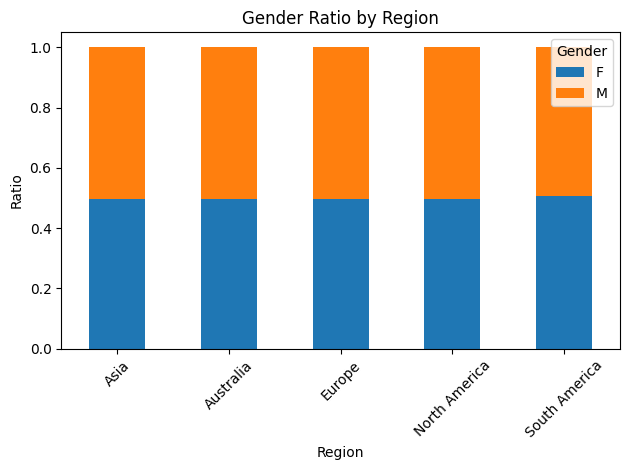

In [ ]:
import matplotlib.pyplot as plt

# region별 gender 비율 계산
gender_ratio = (
    us
    .groupby('Region')['gender']
    .value_counts(normalize=True)
    .unstack()
)

# 그래프
plt.figure()
gender_ratio.plot(kind='bar', stacked=True)
plt.title('Gender Ratio by Region')
plt.xlabel('Region')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

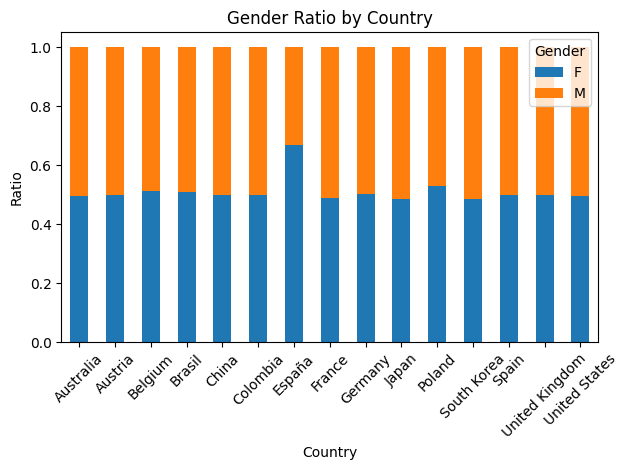

In [19]:
import matplotlib.pyplot as plt

# country별 gender 비율 계산
gender_ratio = (
    us
    .groupby('country')['gender']
    .value_counts(normalize=True)
    .unstack()
)

# 그래프
plt.figure()
gender_ratio.plot(kind='bar', stacked=True)
plt.title('Gender Ratio by Country')
plt.xlabel('Country')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


In [9]:
pr=pd.read_csv('products.csv')
pr

,id,cost,category,name,brand,retail_price,department,sku,distribution_center_id
0,13842,2.51875,Accessories,Low Profile Dyed Cotton Twill Cap - Navy W39S55D,MG,6.25,Women,EBD58B8A3F1D72F4206201DA62FB1204,1
1,13928,2.33835,Accessories,Low Profile Dyed Cotton Twill Cap - Putty W39S55D,MG,5.95,Women,2EAC42424D12436BDD6A5B8A88480CC3,1
2,14115,4.87956,Accessories,Enzyme Regular Solid Army Caps-Black W35S45D,MG,10.99,Women,EE364229B2791D1EF9355708EFF0BA34,1
3,14157,4.64877,Accessories,Enzyme Regular Solid Army Caps-Olive W35S45D (...,MG,10.99,Women,00BD13095D06C20B11A2993CA419D16B,1
4,14273,6.50793,Accessories,Washed Canvas Ivy Cap - Black W11S64C,MG,15.99,Women,F531DC20FDE20B7ADF3A73F52B71D0AF,1
...,...,...,...,...,...,...,...,...,...
29115,5676,12.42338,Pants & Capris,WHAT GOES AROUND COMES AROUND Women's Colette ...,What Goes Around Comes Around,24.17,Women,3A01FC0853EBEBA94FDE4D1CC6FB842A,10
29116,6538,13.67500,Shorts,WHAT GOES AROUND COMES AROUND Women's Mimi Shorts,What Goes Around Comes Around,25.00,Women,741A0099C9AC04C7BFC822CAF7C7459F,10
29117,6712,12.40000,Shorts,WHAT GOES AROUND COMES AROUND Women's Fifi Short,What Goes Around Comes Around,25.00,Women,5726DAF2C9EE0F955ECA58291C26D2F3,10
29118,6821,13.47500,Shorts,WHAT GOES AROUND COMES AROUND Women's Ferguson...,What Goes Around Comes Around,25.00,Women,BA0A4D6ECEA3E9E126DD3B6D77291C97,10


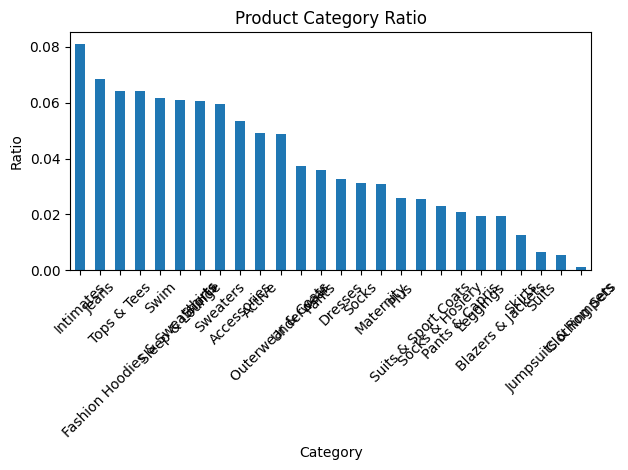

In [17]:
import matplotlib.pyplot as plt

# category 비율 계산
category_ratio = pr['category'].value_counts(normalize=True)

# 그래프
plt.figure()
category_ratio.plot(kind='bar')
plt.title('Product Category Ratio')
plt.xlabel('Category')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
pr['category'].value_counts()

category
Intimates                        2363
Jeans                            1999
Tops & Tees                      1868
Fashion Hoodies & Sweatshirts    1866
Swim                             1798
Sleep & Lounge                   1771
Shorts                           1765
Sweaters                         1737
Accessories                      1559
Active                           1432
Outerwear & Coats                1420
Underwear                        1088
Pants                            1041
Dresses                           955
Socks                             905
Maternity                         898
Plus                              758
Suits & Sport Coats               739
Socks & Hosiery                   666
Pants & Capris                    613
Leggings                          564
Blazers & Jackets                 561
Skirts                            367
Suits                             188
Jumpsuits & Rompers               162
Clothing Sets                      37
Nam

In [29]:
# category → pr_category 매핑 딕셔너리
pr_category_map = {
    # Intimates & Underwear
    'Intimates': 'Intimates & Underwear',
    'Underwear': 'Intimates & Underwear',
    'Socks': 'Intimates & Underwear',
    'Socks & Hosiery': 'Intimates & Underwear',

    # Tops
    'Tops & Tees': 'Tops',
    'Sweaters': 'Tops',
    'Fashion Hoodies & Sweatshirts': 'Tops',

    # Bottoms
    'Jeans': 'Bottoms',
    'Pants': 'Bottoms',
    'Pants & Capris': 'Bottoms',
    'Shorts': 'Bottoms',
    'Skirts': 'Bottoms',
    'Leggings': 'Bottoms',

    # Dresses & One-Piece
    'Dresses': 'Dresses & One-Piece',
    'Jumpsuits & Rompers': 'Dresses & One-Piece',

    # Outerwear
    'Outerwear & Coats': 'Outerwear',
    'Blazers & Jackets': 'Outerwear',

    # Suits & Formalwear
    'Suits': 'Suits & Formalwear',
    'Suits & Sport Coats': 'Suits & Formalwear',

    # Active / Swim / Lounge
    'Swim': 'Active / Swim / Lounge',
    'Sleep & Lounge': 'Active / Swim / Lounge',

    # Sets
    'Clothing Sets': 'Sets',

    # Accessories
    'Accessories': 'Accessories',

    # Special Fit
    'Maternity': 'Special Fit',
    'Plus': 'Special Fit'
}

# pr_category 컬럼 생성
pr['pr_category'] = pr['category'].map(pr_category_map)

# 매핑되지 않은 값 처리 (선택)
pr['pr_category'] = pr['pr_category'].fillna('Other')

# 결과 확인
pr[['category', 'pr_category']].value_counts().head(15)


category                       pr_category           
Intimates                      Intimates & Underwear     2363
Jeans                          Bottoms                   1999
Tops & Tees                    Tops                      1868
Fashion Hoodies & Sweatshirts  Tops                      1866
Swim                           Active / Swim / Lounge    1798
Sleep & Lounge                 Active / Swim / Lounge    1771
Shorts                         Bottoms                   1765
Sweaters                       Tops                      1737
Accessories                    Accessories               1559
Active                         Other                     1432
Outerwear & Coats              Outerwear                 1420
Underwear                      Intimates & Underwear     1088
Pants                          Bottoms                   1041
Dresses                        Dresses & One-Piece        955
Socks                          Intimates & Underwear      905
Name: count, dty

In [33]:
pr['pr_category'].value_counts()

pr_category
Bottoms                   6349
Tops                      5471
Intimates & Underwear     5022
Active / Swim / Lounge    3569
Outerwear                 1981
Special Fit               1656
Accessories               1559
Other                     1432
Dresses & One-Piece       1117
Suits & Formalwear         927
Sets                        37
Name: count, dtype: int64

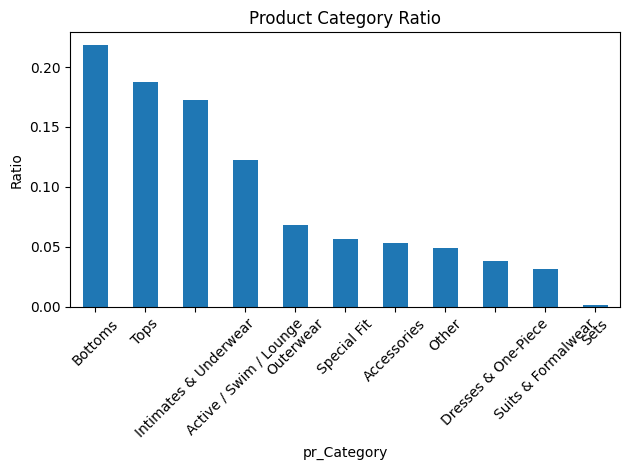

In [32]:
import matplotlib.pyplot as plt

# category 비율 계산
category_ratio = pr['pr_category'].value_counts(normalize=True)

# 그래프
plt.figure()
category_ratio.plot(kind='bar')
plt.title('Product Category Ratio')
plt.xlabel('pr_Category')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
ord=pd.read_csv('orders.csv')
ord

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,48,37,Cancelled,F,2024-08-22 01:33:47+00:00,NaN,NaN,NaN,1
1,76,65,Cancelled,F,2025-08-16 19:33:04+00:00,NaN,NaN,NaN,1
2,92,75,Cancelled,F,2021-09-25 05:34:45+00:00,NaN,NaN,NaN,2
3,119,97,Cancelled,F,2022-06-28 18:03:57+00:00,NaN,NaN,NaN,1
4,124,101,Cancelled,F,2024-06-30 15:21:22+00:00,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...
125462,125448,99984,Shipped,M,2024-09-24 23:10:38+00:00,NaN,2024-09-26 11:37:38+00:00,NaN,2
125463,125458,99989,Shipped,M,2023-01-21 15:20:39+00:00,NaN,2023-01-22 22:29:39+00:00,NaN,1
125464,125459,99991,Shipped,M,2021-03-08 15:48:24+00:00,NaN,2021-03-08 19:52:24+00:00,NaN,1
125465,125460,99993,Shipped,M,2025-02-23 01:52:51+00:00,NaN,2025-02-23 15:22:51+00:00,NaN,1


In [6]:
or_it=pd.read_csv('order_items.csv')
or_it

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,30624,21284,16892,14235,82570,Complete,2025-06-29 07:34:04+00:00,2025-06-29 13:06:36+00:00,2025-07-01 14:24:36+00:00,NaN,0.02
1,48427,33577,26659,14235,130515,Complete,2025-09-09 21:49:07+00:00,2025-09-07 19:50:43+00:00,2025-09-10 03:08:43+00:00,NaN,0.02
2,82129,56839,44907,14235,221524,Complete,2023-09-07 01:59:10+00:00,2023-09-06 06:10:35+00:00,2023-09-07 12:48:35+00:00,NaN,0.02
3,121090,83627,66403,14235,326621,Processing,2025-01-15 17:51:27+00:00,NaN,NaN,NaN,0.02
4,127935,88339,70173,14235,345011,Processing,2022-02-08 09:23:26+00:00,NaN,NaN,NaN,0.02
...,...,...,...,...,...,...,...,...,...,...,...
181743,113974,78775,62416,24447,307364,Shipped,2025-08-06 15:08:50+00:00,2025-08-08 04:47:41+00:00,NaN,NaN,999.00
181744,126924,87654,69629,23546,342301,Shipped,2024-12-26 03:38:37+00:00,2024-12-27 17:40:07+00:00,NaN,NaN,999.00
181745,130014,89749,71310,23546,350606,Shipped,2020-12-30 12:06:57+00:00,2021-01-01 08:27:06+00:00,NaN,NaN,999.00
181746,133368,92072,73185,23546,359652,Shipped,2024-05-10 08:51:46+00:00,2024-05-13 06:12:19+00:00,NaN,NaN,999.00


In [10]:
in_it=pd.read_csv('inventory_items.csv')
in_it

,id,product_id,created_at,sold_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id
0,18988,13844,2024-07-18 08:26:30+00:00,2024-09-13 21:58:30+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
1,18989,13844,2022-09-30 14:02:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
2,98138,13844,2025-08-04 07:18:50+00:00,2025-09-29 01:29:50+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
3,98139,13844,2020-02-23 04:34:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
4,234601,13844,2022-08-03 15:42:36+00:00,2022-08-15 15:20:36+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7
...,...,...,...,...,...,...,...,...,...,...,...,...
490502,359148,25590,2025-07-15 17:05:43+00:00,2025-09-02 08:39:43+00:00,10.39200,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,24.00,Men,F220707C3AFE39D1779E0A34AF72BB7F,3
490503,359149,25590,2022-06-27 11:30:00+00:00,NaN,10.39200,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,24.00,Men,F220707C3AFE39D1779E0A34AF72BB7F,3
490504,462494,25590,2022-06-07 10:10:50+00:00,2022-06-29 18:23:50+00:00,10.39200,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,24.00,Men,F220707C3AFE39D1779E0A34AF72BB7F,3
490505,462495,25590,2020-12-24 17:25:00+00:00,NaN,10.39200,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,24.00,Men,F220707C3AFE39D1779E0A34AF72BB7F,3


In [4]:
ev=pd.read_csv('events.csv')
ev

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type
0,1641988,NaN,3,5bf6673a-4f32-48cd-9494-d4d145f56bb3,2025-08-30 18:34:00+00:00,74.27.71.53,São Paulo,São Paulo,02675-031,Chrome,Adwords,/cancel,cancel
1,1382041,NaN,3,fbf23a93-69af-4084-8132-d6359538ca05,2022-11-29 14:00:00+00:00,2.19.78.31,São Paulo,São Paulo,02675-031,Chrome,Adwords,/cancel,cancel
2,2284087,NaN,3,8539547d-c485-42f9-aa9e-dc1884f77b50,2019-04-14 11:21:00+00:00,203.138.22.14,São Paulo,São Paulo,02675-031,Safari,Facebook,/cancel,cancel
3,1634021,NaN,3,85213078-5a7a-465f-b79f-9d5ffebf9014,2022-04-28 07:19:00+00:00,121.108.191.175,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel
4,1583972,NaN,3,d6752dc3-eb62-4ab7-a799-2aaf60b4ce3b,2025-02-24 18:26:00+00:00,21.253.125.246,Arujá,São Paulo,07432-575,Chrome,Adwords,/cancel,cancel
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2429727,1237743,94964.0,5,84390e8d-ef02-408c-8c3b-ed79062fa07a,2023-07-09 17:19:32+00:00,17.216.194.247,Hounslow,England,TW4,Chrome,Adwords,/purchase,purchase
2429728,1244601,95462.0,13,668664d1-32bb-4221-8607-cdd92282c3d4,2025-11-11 19:20:18+00:00,155.53.206.105,Wigan,England,WN3,Firefox,Adwords,/purchase,purchase
2429729,1239200,95058.0,5,ddf72201-bb2a-4010-8bd5-95326b60295b,2025-12-26 08:22:01+00:00,94.179.128.123,Evesham,England,WR11,IE,Adwords,/purchase,purchase
2429730,1139118,87220.0,5,3cdef64b-668c-44f8-85cf-fa0c4ab2d1a5,2026-01-31 06:59:27+00:00,169.163.122.70,Wolverhampton,England,WV11,Safari,Email,/purchase,purchase


In [3]:
dc=pd.read_csv('distribution_centers.csv')
dc

,id,name,latitude,longitude,distribution_center_geom
0,10,Savannah GA,32.0167,-81.1167,POINT(-81.1167 32.0167)
1,9,Charleston SC,32.7833,-79.9333,POINT(-79.9333 32.7833)
2,1,Memphis TN,35.1174,-89.9711,POINT(-89.9711 35.1174)
3,3,Houston TX,29.7604,-95.3698,POINT(-95.3698 29.7604)
4,7,Philadelphia PA,39.9500,-75.1667,POINT(-75.1667 39.95)
5,8,Mobile AL,30.6944,-88.0431,POINT(-88.0431 30.6944)
6,6,Port Authority of New York/New Jersey NY/NJ,40.6340,-73.7834,POINT(-73.7834 40.634)
7,5,New Orleans LA,29.9500,-90.0667,POINT(-90.0667 29.95)
8,2,Chicago IL,41.8369,-87.6847,POINT(-87.6847 41.8369)
9,4,Los Angeles CA,34.0500,-118.2500,POINT(-118.25 34.05)
